In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [3]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/1.maze_behaviour/")

In [4]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

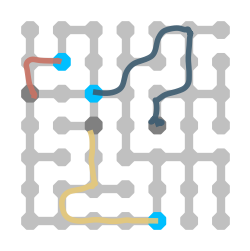

In [ ]:
# example session
session = gs.get_maze_sessions(
    subject_IDs=["m6"], maze_names=["maze_2"], days_on_maze=[11], with_data=["navigation_df"], must_have_data=True
)

# plot example trajectories
reload(tp)
f, ax = plt.subplots(figsize=(3, 3), clear=True)
tp.plot_trial_trajectories(
    session,
    trials=[42, 43, 44],
    smooth_SD=5,
    colors=["#3D5C71", "#C97364", "#E5C879"],
    goal_color="deepskyblue",
    linewidth=4,
    ax=ax,
)
f.savefig(FIG_SAVE_PATH / "example_trajectories.pdf")

In [23]:
from GridMaze.maze import plotting as mp

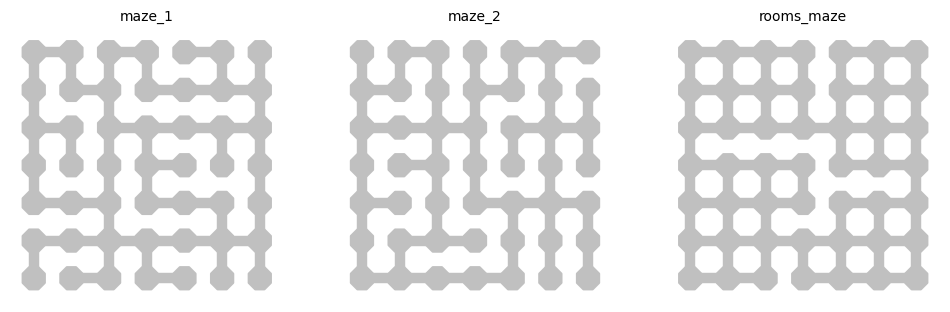

In [47]:
f, axes = plt.subplots(1, 3, figsize=(12, 4), clear=True)
mp.plot_maze_series(axes)
f.savefig(FIG_SAVE_PATH / "maze_series.pdf")

In [6]:
from GridMaze.analysis.behaviour import performance_metrics as pm

basic_behaviour_df = pm.get_basic_behaviour_df()

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     trial    
No. Observations:      210         Method:                 ML       
No. Groups:            6           Scale:                  108.5088 
Min. group size:       35          Log-Likelihood:         -798.0739
Max. group size:       35          Converged:              Yes      
Mean group size:       35.0                                         
--------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------
Intercept              -25.439    4.690 -5.424 0.000 -34.631 -16.247
maze_order              34.539    1.851 18.658 0.000  30.911  38.167
day_on_maze              8.444    0.508 16.633 0.000   7.449   9.439
maze_order:day_on_maze  -2.072    0.254 -8.159 0.000  -2.570  -1.574
Group Var               41.214    2.492           

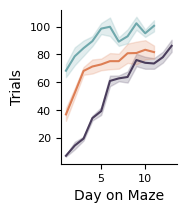

In [27]:
reload(pm)
f, ax = plt.subplots(figsize=(1.5, 2))
pm._plot_trials(
    basic_behaviour_df,
    ax=ax,
    legend=False,
    colors=["#4A3D5C", "#DD7E54", "#6FA8AC"],
    print_stats=True,
)
f.savefig(FIG_SAVE_PATH / "trials.pdf")

/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/nfs/nhome/live/pdoohan/.conda/envs/goalNav_mEC/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  n_excess_steps
No. Observations:    210      Method:              ML            
No. Groups:          6        Scale:               13.1579       
Min. group size:     35       Log-Likelihood:      -568.5647     
Max. group size:     35       Converged:           Yes           
Mean group size:     35.0                                        
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              18.420    1.354 13.601 0.000 15.766 21.075
maze_order             -6.031    0.645 -9.355 0.000 -7.294 -4.767
day_on_maze            -1.565    0.177 -8.851 0.000 -1.911 -1.218
maze_order:day_on_maze  0.497    0.088  5.618 0.000  0.324  0.670
Group Var               0.000                                    



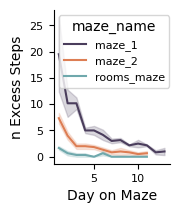

In [28]:
reload(pm)
f, ax = plt.subplots(figsize=(1.5, 2))
pm._plot_n_excess_steps(
    basic_behaviour_df,
    ax=ax,
    legend=True,
    colors=["#4A3D5C", "#DD7E54", "#6FA8AC"],
    print_stats=True,
)
f.savefig(FIG_SAVE_PATH / "excess_steps.pdf")

### New mixture of strategies modelling

In [13]:
from GridMaze.analysis.navigation_strategies import get_input_data as gid
from GridMaze.analysis.navigation_strategies import fits as nsf

In [14]:
navigation_strategies_df = gid.get_navigation_strategies_df()

In [15]:
weights_df = nsf.get_strategy_weights(navigation_strategies_df)

maze_1
  habit: T(5)=22.781, p=0.000
  vector: T(5)=24.581, p=0.000
  structure: T(5)=40.060, p=0.000
maze_2
  habit: T(5)=14.933, p=0.000
  vector: T(5)=18.314, p=0.000
  structure: T(5)=46.078, p=0.000
rooms_maze
  habit: T(5)=26.413, p=0.000
  vector: T(5)=12.469, p=0.000
  structure: T(5)=30.925, p=0.000


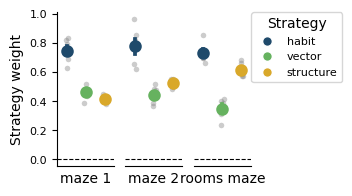

In [25]:
reload(nsf)
fig, axes = plt.subplots(1, 3, figsize=(2.5, 2), sharey=True)
nsf.plot_strategy_weights(weights_df, print_stats=True, colors=["#1F4A6B", "#66B25F", "#D9A82A"], axes=axes)
fig.savefig(FIG_SAVE_PATH / "strategy_weights.pdf")

In [17]:
from GridMaze.analysis.navigation_strategies import comparisons as com


--- [H≠S: habit != structure]: 12120/33143 (36.6%) decisions kept ---

--- [V≠S: vector != structure]: 7490/33143 (22.6%) decisions kept ---

--- [V≠S & H≠S: vector != structure & habit != structure]: 2790/33143 (8.4%) decisions kept ---
  H≠S vs chance (0.325): T(5)=11.632, p=8.25e-05, n=6
  V≠S vs chance (0.350): T(5)=33.810, p=4.26e-07, n=6
  V≠S & H≠S vs chance (0.317): T(5)=2.821, p=0.0371, n=6
  P(H≠S)=0.543 vs P(V≠S)=0.628: T(5)=-6.637, p=0.00117, n=6
  P(H≠S)=0.543 vs P(V≠S & H≠S)=0.380: T(5)=17.955, p=9.84e-06, n=6
  P(V≠S)=0.628 vs P(V≠S & H≠S)=0.380: T(5)=14.565, p=2.75e-05, n=6


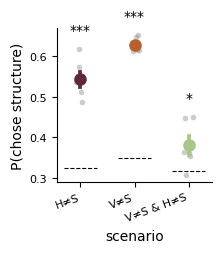

In [22]:
reload(com)
fig, ax = plt.subplots(1, 1, figsize=(2, 2))

com.plot_optimal_across_scenarios(
    navigation_strategies_df,
    maze_names=["maze_1", "maze_2"],
    decision_point_filter="only",
    colors=["#5C2940", "#B85F2F", "#A8C58A"],
    last_n_days_on_maze=7,
    ax=ax,
    print_stats=True,
    show_corrected_chance=False,
)

fig.savefig(FIG_SAVE_PATH / "p_optimal_across_scenarios.pdf")

## Supp.

In [23]:
weights_over_time_df = nsf.get_strategy_weights_over_days(navigation_strategies_df)

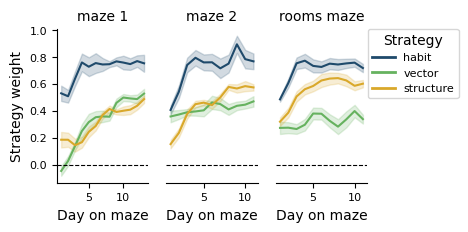

In [24]:
reload(nsf)
fig, axes = plt.subplots(1, 3, figsize=(4, 2), sharey=True)
nsf.plot_strategy_weights_over_days(weights_over_time_df, colors=["#1F4A6B", "#66B25F", "#D9A82A"], axes=axes)
fig.savefig(FIG_SAVE_PATH / "strategy_weights_over_sessions.pdf")

In [21]:
reload(nsf)
model_eval_df = nsf.get_cv_model_comparisons(navigation_strategies_df, verbose=False)

no_backtracking_penalty: T(5)=23.783, p=0.000
no_habit: T(5)=8.352, p=0.000
no_structure: T(5)=24.570, p=0.000
no_vector: T(5)=11.299, p=0.000


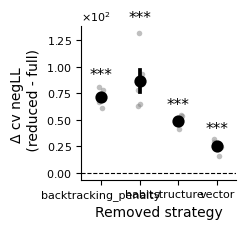

In [36]:
fig, ax = plt.subplots(figsize=(2, 2))
nsf.plot_strategy_delta_negLL(model_eval_df, print_stats=True, ax=ax)
fig.savefig(FIG_SAVE_PATH / "model_evaluation.pdf")